<a href="https://colab.research.google.com/github/amitbhaskar112/codealpha_IrisFlowerClassification/blob/main/IrisFlowerClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install -q kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle (2).json to kaggle (2).json


{'kaggle (2).json': b'{"username":"jatins4567890","key":"5b191a945ff7e13eda81ac44a4f39d3d"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp 'kaggle (7).json' ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle (7).json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [5]:
! kaggle.com/datasets//https://www.kaggle.com/datasets/saurabh00007/iriscsv

/bin/bash: line 1: kaggle.com/datasets//https://www.kaggle.com/datasets/saurabh00007/iriscsv: No such file or directory


In [6]:
import zipfile
import os


!kaggle datasets download -d saurabh00007/iriscsv --force


zip_file_name = 'iriscsv.zip' # Make sure this matches the downloaded file name


destination_dir = 'datasets/saurabh00007/iriscsv'
os.makedirs(destination_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall(destination_dir)

print(f"All files extracted to: {destination_dir}")
print("Extracted files:")
for root, dirs, files in os.walk(destination_dir):
    for name in files:
      print(os.path.join(root, name))

Dataset URL: https://www.kaggle.com/datasets/saurabh00007/iriscsv
License(s): CC0-1.0
100% 1.28k/1.28k [00:00<00:00, 4.15MB/s]

All files extracted to: datasets/saurabh00007/iriscsv
Extracted files:
datasets/saurabh00007/iriscsv/Iris.csv


In [7]:
import pandas as pd


csv_file_path = 'datasets/saurabh00007/iriscsv/Iris.csv'


df = pd.read_csv(csv_file_path)


print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [8]:
import pandas as pd

csv_file_path = 'datasets/saurabh00007/iriscsv/Iris.csv'
df = pd.read_csv(csv_file_path)

df.info()
df.describe()
df['Species'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


Correlation Matrix:
              petal_length  petal_width
petal_length      1.000000     0.962865
petal_width       0.962865     1.000000


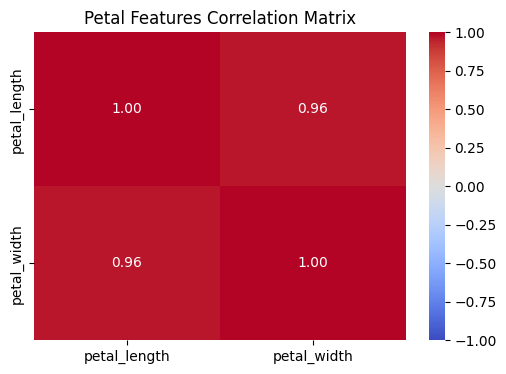

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Iris dataset load karein
df = sns.load_dataset("iris")

# 2. Sirf Petal features (petal_length & petal_width) select karein
petal_df = df[["petal_length", "petal_width"]]

# 3. Correlation Matrix calculate karein
correlation_matrix = petal_df.corr()
print("Correlation Matrix:")
print(correlation_matrix)

# 4. Correlation Matrix ko Heatmap ke through visualize karein
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Petal Features Correlation Matrix")
plt.show()

Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



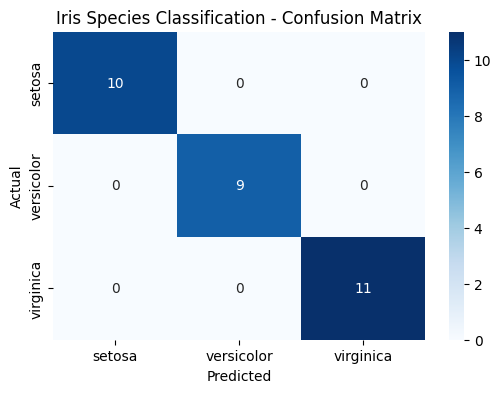

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns

# 1. Dataset load karein
df = sns.load_dataset("iris")

# 2. Features (X) aur Target (y) alag karein
X = df[["petal_length", "petal_width"]]  # Sirf Petal features
y = df["species"]                       # Target column (Setosa, Versicolor, Virginica)

# 3. Data ko Training aur Testing sets me split karein (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Classification Model select aur train karein
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 5. Testing data par Predictions karein
y_pred = model.predict(X_test)

# 6. Model ki Performance evaluate karein
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 7. Confusion Matrix plot karein
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Iris Species Classification - Confusion Matrix")
plt.show()

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 1. Dataset load karein
df = sns.load_dataset("iris")

# 2. Features (X) aur Target (y) alag karein
X = df[["petal_length", "petal_width"]]
y = df["species"]

# 3. Model define karein
model = RandomForestClassifier(random_state=42)

# 4. Stratified K-Fold setup (5 splits)
# Stratified ensure karta hai ki har fold me teeno species ka ratio barabar rahe
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 5. Cross-validation run karein
scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")

# 6. Results print karein
print("Har Fold ki Accuracy:")
for i, score in enumerate(scores, 1):
    print(f"Fold {i}: {score * 100:.2f}%")

print("\n--- Summary ---")
print(f"Mean Accuracy: {scores.mean() * 100:.2f}%")
print(f"Standard Deviation: {scores.std() * 100:.2f}%")

Har Fold ki Accuracy:
Fold 1: 100.00%
Fold 2: 96.67%
Fold 3: 93.33%
Fold 4: 100.00%
Fold 5: 93.33%

--- Summary ---
Mean Accuracy: 96.67%
Standard Deviation: 2.98%


In [12]:
pip install streamlit seaborn scikit-learn pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 71.5 MB/s eta 0:00:00


In [13]:
!streamlit run app.py

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py


In [14]:
import pandas as pd
import seaborn as sns
import streamlit as st
from sklearn.ensemble import RandomForestClassifier

# Page configuration
st.set_page_config(
    page_title="Iris Species Predictor", page_icon="🌺", layout="centered"
)


# Model ko cache/train karne ke liye function
@st.cache_resource
def train_model():
    df = sns.load_dataset("iris")
    X = df[["petal_length", "petal_width"]]
    y = df["species"]

    model = RandomForestClassifier(random_state=42)
    model.fit(X, y)
    return model


model = train_model()

# Web Page UI Design
st.title("🌺 Iris Flower Species Predictor")
st.write(
    "Enter **Petal Length** and **Petal Width** to predict the Iris species."
)

st.divider()

# Input UI Layout (2 Columns)
col1, col2 = st.columns(2)

with col1:
    petal_length = st.number_input(
        "Petal Length (cm):",
        min_value=1.0,
        max_value=7.0,
        value=3.5,
        step=0.1,
    )

with col2:
    petal_width = st.number_input(
        "Petal Width (cm):", min_value=0.1, max_value=2.5, value=1.0, step=0.1
    )

st.divider()

# Prediction Button & Logic
if st.button("Predict Species", type="primary", use_container_width=True):
    # Model prediction
    input_data = pd.DataFrame(
        [[petal_length, petal_width]], columns=["petal_length", "petal_width"]
    )
    prediction = model.predict(input_data)[0]
    probabilities = model.predict_proba(input_data)[0]
    classes = model.classes_

    # Output Display
    st.subheader("Results:")
    st.success(f"Predicted Species: **{prediction.upper()}** 🎉")

    # Display Prediction Probabilities
    st.write("### Prediction Confidence:")
    for species_name, prob in zip(classes, probabilities):
        st.write(f"**{species_name.capitalize()}**: {prob * 100:.2f}%")
        st.progress(float(prob))

2026-09-20 17:34:01.826 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 17:34:01.828 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 17:34:01.962 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 17:34:02.147 
  command:

    streamlit run /usr/local/lib/python3.13/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-09-20 17:34:02.148 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 17:34:02.149 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 17:34:02.150 Thread 'MainThread'

In [15]:
%%writefile app.py
import pandas as pd
import seaborn as sns
import streamlit as st
from sklearn.ensemble import RandomForestClassifier

# Page configuration
st.set_page_config(
    page_title="Iris Species Predictor", page_icon="🌺", layout="centered"
)


# Model ko cache/train karne ke liye function
@st.cache_resource
def train_model():
    df = sns.load_dataset("iris")
    X = df[["petal_length", "petal_width"]]
    y = df["species"]

    model = RandomForestClassifier(random_state=42)
    model.fit(X, y)
    return model


model = train_model()

# Web Page UI Design
st.title("🌺 Iris Flower Species Predictor")
st.write(
    "Enter **Petal Length** and **Petal Width** to predict the Iris species."
)

st.divider()

# Input UI Layout (2 Columns)
col1, col2 = st.columns(2)

with col1:
    petal_length = st.number_input(
        "Petal Length (cm):",
        min_value=1.0,
        max_value=7.0,
        value=3.5,
        step=0.1,
    )

with col2:
    petal_width = st.number_input(
        "Petal Width (cm):", min_value=0.1, max_value=2.5, value=1.0, step=0.1
    )

st.divider()

# Prediction Button & Logic
if st.button("Predict Species", type="primary", use_container_width=True):
    # Model prediction
    input_data = pd.DataFrame(
        [[petal_length, petal_width]], columns=["petal_length", "petal_width"]
    )
    prediction = model.predict(input_data)[0]
    probabilities = model.predict_proba(input_data)[0]
    classes = model.classes_

    # Output Display
    st.subheader("Results:")
    st.success(f"Predicted Species: **{prediction.upper()}** 🎉")

    # Display Prediction Probabilities
    st.write("### Prediction Confidence:")
    for species_name, prob in zip(classes, probabilities):
        st.write(f"**{species_name.capitalize()}**: {prob * 100:.2f}%")
        st.progress(float(prob))

Writing app.py


In [16]:
%%writefile index.html
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Iris Species Predictor</title>
    <style>
        body {
            font-family: Arial, sans-serif;
            background-color: #f4f7f6;
            display: flex;
            justify-content: center;
            align-items: center;
            height: 100vh;
            margin: 0;
        }
        .card {
            background: #ffffff;
            padding: 25px;
            border-radius: 10px;
            box-shadow: 0 4px 10px rgba(0,0,0,0.1);
            width: 320px;
        }
        h2 { text-align: center; color: #333; margin-top: 0; }
        .input-group { margin-bottom: 15px; }
        label { display: block; margin-bottom: 5px; font-weight: bold; color: #555; }
        input {
            width: 100%;
            padding: 8px;
            box-sizing: border-box;
            border: 1px solid #ccc;
            border-radius: 5px;
        }
        button {
            width: 100%;
            padding: 10px;
            background-color: #28a745;
            color: white;
            border: none;
            border-radius: 5px;
            font-size: 16px;
            cursor: pointer;
        }
        button:hover { background-color: #218838; }
        .result {
            margin-top: 20px;
            padding: 10px;
            border-radius: 5px;
            text-align: center;
            font-weight: bold;
            display: none;
        }
    </style>
</head>
<body>

<div class="card">
    <h2>🌺 Iris Predictor</h2>

    <div class="input-group">
        <label for="pLength">Petal Length (cm):</label>
        <input type="number" id="pLength" step="0.1" value="1.4" min="0">
    </div>

    <div class="input-group">
        <label for="pWidth">Petal Width (cm):</label>
        <input type="number" id="pWidth" step="0.1" value="0.2" min="0">
    </div>

    <button onclick="predict()">Predict Species</button>

    <div id="output" class="result"></div>
</div>

<script>
    function predict() {
        let length = parseFloat(document.getElementById('pLength').value);
        let width = parseFloat(document.getElementById('pWidth').value);
        let outputDiv = document.getElementById('output');

        if (isNaN(length) || isNaN(width)) {
            outputDiv.style.display = "block";
            outputDiv.style.backgroundColor = "#f8d7da";
            outputDiv.style.color = "#721c24";
            outputDiv.innerText = "Please enter valid values.";
            return;
        }

        let species = "";

        // Decision Tree Rules based on Petal Length & Width
        if (length <= 2.45) {
            species = "Setosa 🌸";
        } else if (width <= 1.75) {
            if (length <= 4.95) {
                species = "Versicolor 🌿";
            } else {
                species = "Virginica 🌺";
            }
        } else {
            species = "Virginica 🌺";
        }

        outputDiv.style.display = "block";
        outputDiv.style.backgroundColor = "#d4edda";
        outputDiv.style.color = "#155724";
        outputDiv.innerText = "Predicted Species: " + species;
    }
</script>

</body>
</html>

Writing index.html
